In [54]:
import os 
import numpy as np
import pandas as pd
from matplotlib import pyplot as pit

### Wczytywanie i przygotowywanie danych


In [39]:
# Wyświetlanie listy kodów produktów z pobranymi opiniami

katalog = "./opinions"
kody = os.listdir(katalog)

print("lista kodów", katalog)
for kod in kody:
    print(kod[:-5])

   

lista kodów ./opinions
100911747
176611863
84514582


In [48]:
# wczytawanie danych z plików .json do obiektu przypominającego tabele
product_id = input("podaj kod produktu: ")
reviews = pd.read_json(f"./opinions/{product_id}.json").set_index("review_id")
reviews

,author,recommendation,stars,content,pros,cons,likes,dislikes,published,purchased
review_id,,,,,,,,,,
12535429,g...6,None,3/5,Instalacja łatwa. Oprogramowanie HP Smart bezp...,"[czyste napełnianie atramentem, niski koszt wy...",[jakość wydruków],19,3,2020-05-28 08:02:51,2020-05-04 22:29:44
13551598,b...a,Polecam,4/5,"Wykonana dobrze, trochę za duża, z ledwością m...","[czyste napełnianie atramentem, głośność pracy]",[],3,3,2020-12-10 19:41:04,2020-12-04 21:02:01
18299406,U...o,Polecam,"4,5/5",Po 1 dniu uzytkowania mozna stwierdzic 1-polac...,"[czyste napełnianie atramentem, jakość wydrukó...",[głośność pracy],0,0,2024-01-12 21:03:08,2024-01-09 18:20:01
15226709,k...l,Polecam,4/5,Wszystko z opisu się zgadza. Baaardzo ekonomic...,[],[],3,0,2021-11-18 17:47:41,2021-11-01 18:36:33
13501735,g...k,None,"3,5/5",produkt na wstępie nie ruszył bo był problem z...,"[jakość wydruków, jakość wydruku, szybkość wyd...",[głośność pracy],4,0,2020-12-04 00:11:48,2020-11-17 18:04:01
...,...,...,...,...,...,...,...,...,...,...
13466015,w...d,Nie polecam,1/5,badziew,[],[],1,0,2020-11-28 17:08:14,2020-10-28 14:03:29
15730485,b...o,Nie polecam,2/5,POLECAM,[],[],0,0,2022-02-21 10:21:10,2022-02-14 08:19:16
15798075,b...o,Nie polecam,"0,5/5",polecam,[],[],0,1,2022-03-09 11:10:06,2022-03-08 11:01:43


In [49]:
# transformacja danych
reviews.stars = reviews.stars.apply(lambda s: s.split("/")[0].replace(",", ".")).astype(float)
reviews.likes = reviews.likes.astype(int)
reviews.dislikes = reviews.dislikes.astype(int)
reviews

,author,recommendation,stars,content,pros,cons,likes,dislikes,published,purchased
review_id,,,,,,,,,,
12535429,g...6,None,3.0,Instalacja łatwa. Oprogramowanie HP Smart bezp...,"[czyste napełnianie atramentem, niski koszt wy...",[jakość wydruków],19,3,2020-05-28 08:02:51,2020-05-04 22:29:44
13551598,b...a,Polecam,4.0,"Wykonana dobrze, trochę za duża, z ledwością m...","[czyste napełnianie atramentem, głośność pracy]",[],3,3,2020-12-10 19:41:04,2020-12-04 21:02:01
18299406,U...o,Polecam,4.5,Po 1 dniu uzytkowania mozna stwierdzic 1-polac...,"[czyste napełnianie atramentem, jakość wydrukó...",[głośność pracy],0,0,2024-01-12 21:03:08,2024-01-09 18:20:01
15226709,k...l,Polecam,4.0,Wszystko z opisu się zgadza. Baaardzo ekonomic...,[],[],3,0,2021-11-18 17:47:41,2021-11-01 18:36:33
13501735,g...k,None,3.5,produkt na wstępie nie ruszył bo był problem z...,"[jakość wydruków, jakość wydruku, szybkość wyd...",[głośność pracy],4,0,2020-12-04 00:11:48,2020-11-17 18:04:01
...,...,...,...,...,...,...,...,...,...,...
13466015,w...d,Nie polecam,1.0,badziew,[],[],1,0,2020-11-28 17:08:14,2020-10-28 14:03:29
15730485,b...o,Nie polecam,2.0,POLECAM,[],[],0,0,2022-02-21 10:21:10,2022-02-14 08:19:16
15798075,b...o,Nie polecam,0.5,polecam,[],[],0,1,2022-03-09 11:10:06,2022-03-08 11:01:43


### Podstawowe statystyki


In [50]:
reviews_count = reviews.shape[0]
pros_count = reviews.pros.astype(bool).sum()
cons_count = reviews.cons.astype(bool).sum()
pros_cons_count = reviews.apply(lambda r: bool(r.pros) and bool(r.cons), axis=1).sum()
average_stars = round(reviews.stars.mean(),2)
print(f"liczba opini o produkcie: {reviews_count}")
print(f"liczba opini o produkcie: {reviews_count}")
print(f"liczba opini o produkcie: {reviews_count}")
print(f"liczba opini o produkcie: {reviews_count}")
print(f"liczba opini o produkcie: {reviews_count}")

liczba opini o produkcie: 86
liczba opini o produkcie: 86
liczba opini o produkcie: 86
liczba opini o produkcie: 86
liczba opini o produkcie: 86


In [52]:
pros = reviews.pros.explode().value_counts()
cons = reviews.cons.explode().value_counts
pros

pros
jakość wydruków                  34
szybkość wydruku                 33
jakość wydruku                   28
głośność pracy                   23
wydajność                        15
czyste napełnianie atramentem    11
wydajna                          10
niski koszt wydruku               9
tani atrament                     4
drukowanie poprzez e-mail         3
nowoczesność                      3
doskonały design                  2
innowacyjność                     2
podajnik dokumentów               1
zajmuje mało miejsc               1
Name: count, dtype: int64

In [ ]:
recommendation = reviews.recommendation.value_counts(dropna=False).sort_index().reindex("nie polecam", "polecam", None)
recommendation

recommendation
Nie polecam     7
Polecam        73
None            6
Name: count, dtype: int64

<Axes: >

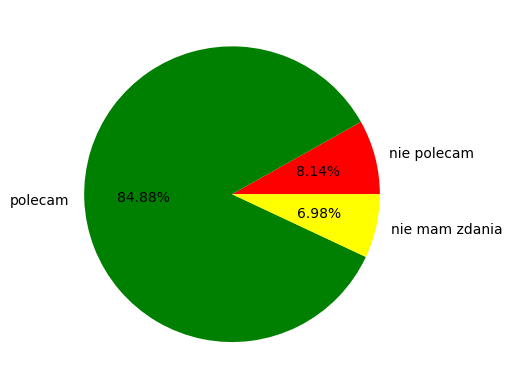

In [65]:
recommendation.plot.pie(
    label = "",
    labels = ["nie polecam", "polecam", "nie mam zdania"],
    autopct = lambda x: f"{x:1.2f}%" if x>0 else "",
    colors = ["red", "green", "yellow"]
)